`conda activate r_env_standr`

In [ ]:
suppressPackageStartupMessages({
    library(Seurat)
    library(dplyr)
    library(here)
    library(tibble)
    # library(SCpubr)
    library(dittoSeq)
    library(stringr)
    library(data.table)
    library(tidyverse)
    library(patchwork) 
    library(RColorBrewer) 
    library(ggplot2)
    library(dplyr)
    library(reticulate)
    library(jsonlite)
    options(stringsAsFactors = FALSE)
    set.seed(123)
})

Warning message:
“package ‘ggplot2’ was built under R version 4.3.3”


In [ ]:
use_condaenv('seacells')

In [ ]:
malignant <- readRDS('/projects/0/einf2548/cruiz/dmg/data/malignant_rna.rds')
malignant

An object of class Seurat 
19248 features across 291695 samples within 1 assay 
Active assay: RNA (19248 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, umap

In [ ]:
nmf_assignment <- readRDS('nmf/data/nmf_assigment_malignant_no_core_programs.rds')
nmf_assignment

,MP_Assignment
,<chr>
BT042_PD_CCGTTCATCTATGTGG-1,unresolved
BT042_PD_CTACCTGGTATGAAAC-1,MP_2_1
BT042_PD_TTGCATTTCCTGTAGA-1,MP_2_1
BT042_PD_GTGCTGGGTAACGCGA-1,MP_2_1
BT042_PD_CTTCTAAAGACGCATG-1,MP_2_1
BT042_PD_CCTCACACAAAGCTAA-1,MP_5_1
BT042_PD_ACAAGCTGTGGCTAGA-1,MP_5_1
BT042_PD_TTCCGGTAGGGAGTTC-1,MP_2_1
BT042_PD_ACAGAAAGTCTATGAC-1,MP_5_1


In [ ]:
malignant <- AddMetaData(malignant, metadata = nmf_assignment)

In [ ]:
malignant$NMF <- malignant$MP_Assignment

In [ ]:
malignant$NMF <- sub("_1$", "", malignant$NMF)
malignant$NMF <- factor(malignant$NMF, 
                      levels = c( "MP_2", "MP_3", "MP_4", "MP_5", 
                                  "MP_7", "MP_8", "MP_9", 
                                 "MP_11", "MP_12", "MP_13", "unresolved"))

In [ ]:
sc <- import("scanpy")

In [ ]:
adata <- sc$read_h5ad("/projects/0/einf2548/cruiz/dmg/data/trajectories/malignant_rna_dm.h5ad")
adata

AnnData object with n_obs × n_vars = 254854 × 0
    obs: 'scDblFinder.class', 'scDblFinder.score', 'ID', 'SampleID', 'Batch_for_correction', 'Study', 'Institute', 'Preservation_method', 'Diagnosis', 'Tumor_type', 'Tumor_subtype', 'Location', 'Source', 'Clinical_status', 'Isolation_method', 'Sc_platform_RNA', 'Sc_platform_ATAC', 'Sc_multiome', 'Raw_data_available', 'Counts', 'Genome_version', 'Paired_sample', 'Multisector', 'Gender', 'Age_years', 'Dexamethasone_prior_surgery', 'Survival', 'Survival_months', 'Mitosis', 'Ki67', 'Methylation_array', 'H3F3A', 'H3C3', 'HIST1H3B', 'HIST2H3C', 'TP53', 'EGFR', 'PDGFRA', 'SUFU', 'NF1', 'pTERT', 'PIK3CA', 'PIK3R1', 'ATRX', 'PTEN', 'ASXL1', 'BCOR', 'BCORL1', 'SMC1A', 'WT1', 'PPM1D', 'ACVR1', 'TSHR', 'BRAF', 'GNAQ', 'LMNA', 'KIT', 'ARID1A', 'KRAS', 'Other', 'cell_id', 'modality', 'domain', 'leiden_1', 'leiden_1_3', 'leiden_1_5', 'leiden_1_8', 'leiden_2', 'leiden_2_3', 'leiden_2_5', 'leiden_2_8', 'leiden_3', 'louvain_1', 'louvain_1_3', 'louvain_1_5'

In [ ]:
X_diffmap <- as.matrix(reticulate::py_get_item(adata$obsm, 'X_diffmap'))
X_diffmap <- X_diffmap[, -1] # looking at the source code in scanpy for plotting, DC0 is deleted from the plotting
colnames(X_diffmap) <- 1:14
rownames(X_diffmap) <- adata$obs$cell_names
X_diffmap

,1,2,3,4,5,6,7,8,9,10,11,12,13,14
BT042_pons_2_AGGCCACCATGGCCAC-1,-0.0005145163,-2.508010e-04,-0.0002883044,7.573584e-04,-9.165640e-04,3.676859e-04,2.062622e-03,0.0019979645,0.0007200030,-7.629771e-04,1.434992e-04,1.654733e-04,-1.192893e-06,-7.797412e-04
BT042_pons_2_CCCTCAAAGTAGCTCT-1,-0.0014004086,9.527665e-04,0.0004419684,8.654728e-05,-3.072046e-04,1.667455e-04,1.028256e-03,0.0012481306,0.0025479111,-1.537308e-03,7.080656e-04,2.943084e-04,6.431906e-04,-4.696289e-03
BT042_pons_2_TGATCAGTCCTACAAG-1,0.0009883358,1.979107e-05,0.0001445088,5.781820e-04,-8.454632e-04,-1.761983e-04,-8.229745e-05,0.0001664895,0.0009966498,1.375902e-05,-5.418321e-04,9.404505e-05,-2.187701e-04,1.218564e-04
BT042_pons_2_GAAATGAGTACTAAGA-1,-0.0017349309,1.330720e-03,0.0009360632,-2.690418e-04,-1.239842e-04,-7.863116e-04,7.214471e-04,0.0008608025,0.0023680781,-2.194576e-03,6.522423e-04,6.377645e-04,5.517326e-04,-2.552241e-03
BT042_pons_2_CATCCGTGTTAAGACA-1,-0.0018498147,1.504025e-03,0.0012156954,-3.267589e-04,-8.011686e-05,-1.329591e-04,2.411430e-04,0.0005102399,0.0021506948,-2.686409e-03,9.205049e-04,1.582497e-04,7.311428e-04,-1.773335e-03
BT042_pons_2_TCTATCAGTGGAGGTT-1,0.0004447911,-1.648323e-03,-0.0001278239,4.783264e-04,-1.398508e-03,-1.728163e-04,3.252778e-03,-0.0051164040,0.0000795006,-1.565536e-03,1.396497e-03,-3.042889e-03,4.286651e-04,1.190217e-03
BT042_pons_2_TCTGGCTTCGAGAACG-1,-0.0015778177,9.838792e-04,0.0002698596,1.237287e-04,-1.999522e-04,2.438021e-04,8.061407e-04,0.0010390086,0.0016680871,-1.105545e-03,5.767649e-04,4.758814e-05,4.513331e-04,-3.199839e-03
BT042_pons_2_CCGATGGTCTGTAACG-1,0.0007818135,-1.310925e-03,0.0001943336,8.163385e-04,-1.010841e-03,-1.553926e-04,2.258902e-05,-0.0005024608,0.0010405477,-1.005365e-04,5.704186e-05,7.871887e-04,-5.550375e-04,1.781960e-03
BT042_pons_2_GCAGCCAAGGACAAGA-1,-0.0018954413,1.982253e-03,0.0022438145,-5.681015e-04,-3.085421e-04,-1.101666e-02,6.769263e-04,0.0002447188,-0.0014786659,1.619323e-03,-2.042079e-04,-7.359377e-04,-1.771641e-06,7.966118e-04
BT042_pons_2_TGGCGTGCATACTGAC-1,-0.0017177878,1.091065e-03,0.0001508031,-1.065929e-04,-2.753832e-05,-7.386762e-04,7.380467e-04,0.0007641446,0.0017192257,-8.337021e-04,2.117591e-04,5.087230e-04,2.407621e-04,-1.764375e-03


In [ ]:
malignant <- subset(malignant, cells = adata$obs$cell_names)
malignant

An object of class Seurat 
19248 features across 254854 samples within 1 assay 
Active assay: RNA (19248 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, umap

In [ ]:
rownames_to_match <- rownames(malignant@meta.data)

# Reorder the rows of X_diffmap based on the rownames_to_match
X_diffmap_reordered <- X_diffmap[match(rownames_to_match, rownames(X_diffmap)), ]
X_diffmap_reordered

,1,2,3,4,5,6,7,8,9,10,11,12,13,14
BT042_pons_2_AGGCCACCATGGCCAC-1,-0.0005145163,-2.508010e-04,-0.0002883044,7.573584e-04,-9.165640e-04,3.676859e-04,2.062622e-03,0.0019979645,0.0007200030,-7.629771e-04,1.434992e-04,1.654733e-04,-1.192893e-06,-7.797412e-04
BT042_pons_2_CCCTCAAAGTAGCTCT-1,-0.0014004086,9.527665e-04,0.0004419684,8.654728e-05,-3.072046e-04,1.667455e-04,1.028256e-03,0.0012481306,0.0025479111,-1.537308e-03,7.080656e-04,2.943084e-04,6.431906e-04,-4.696289e-03
BT042_pons_2_TGATCAGTCCTACAAG-1,0.0009883358,1.979107e-05,0.0001445088,5.781820e-04,-8.454632e-04,-1.761983e-04,-8.229745e-05,0.0001664895,0.0009966498,1.375902e-05,-5.418321e-04,9.404505e-05,-2.187701e-04,1.218564e-04
BT042_pons_2_GAAATGAGTACTAAGA-1,-0.0017349309,1.330720e-03,0.0009360632,-2.690418e-04,-1.239842e-04,-7.863116e-04,7.214471e-04,0.0008608025,0.0023680781,-2.194576e-03,6.522423e-04,6.377645e-04,5.517326e-04,-2.552241e-03
BT042_pons_2_CATCCGTGTTAAGACA-1,-0.0018498147,1.504025e-03,0.0012156954,-3.267589e-04,-8.011686e-05,-1.329591e-04,2.411430e-04,0.0005102399,0.0021506948,-2.686409e-03,9.205049e-04,1.582497e-04,7.311428e-04,-1.773335e-03
BT042_pons_2_TCTATCAGTGGAGGTT-1,0.0004447911,-1.648323e-03,-0.0001278239,4.783264e-04,-1.398508e-03,-1.728163e-04,3.252778e-03,-0.0051164040,0.0000795006,-1.565536e-03,1.396497e-03,-3.042889e-03,4.286651e-04,1.190217e-03
BT042_pons_2_TCTGGCTTCGAGAACG-1,-0.0015778177,9.838792e-04,0.0002698596,1.237287e-04,-1.999522e-04,2.438021e-04,8.061407e-04,0.0010390086,0.0016680871,-1.105545e-03,5.767649e-04,4.758814e-05,4.513331e-04,-3.199839e-03
BT042_pons_2_CCGATGGTCTGTAACG-1,0.0007818135,-1.310925e-03,0.0001943336,8.163385e-04,-1.010841e-03,-1.553926e-04,2.258902e-05,-0.0005024608,0.0010405477,-1.005365e-04,5.704186e-05,7.871887e-04,-5.550375e-04,1.781960e-03
BT042_pons_2_GCAGCCAAGGACAAGA-1,-0.0018954413,1.982253e-03,0.0022438145,-5.681015e-04,-3.085421e-04,-1.101666e-02,6.769263e-04,0.0002447188,-0.0014786659,1.619323e-03,-2.042079e-04,-7.359377e-04,-1.771641e-06,7.966118e-04
BT042_pons_2_TGGCGTGCATACTGAC-1,-0.0017177878,1.091065e-03,0.0001508031,-1.065929e-04,-2.753832e-05,-7.386762e-04,7.380467e-04,0.0007641446,0.0017192257,-8.337021e-04,2.117591e-04,5.087230e-04,2.407621e-04,-1.764375e-03


In [ ]:
malignant@reductions$diffusion <- Seurat::CreateDimReducObject(
  embeddings = X_diffmap_reordered,
  key="DC_",
  assay="RNA"
)

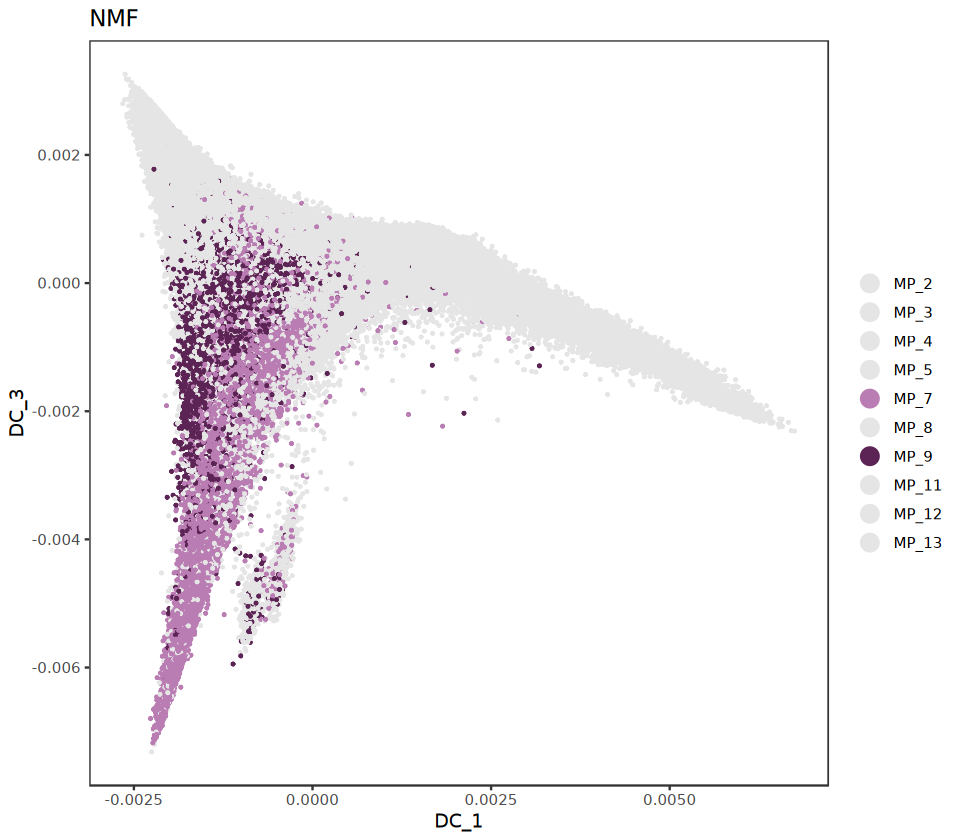

In [ ]:
options(repr.plot.height = 7, repr.plot.width = 8)
dittoSeq::dittoDimPlot(subset(malignant, NMF != c('unresolved')), var = 'NMF',
                       size = 1,
                       do.raster = TRUE,
                       order='randomize',
                       show.grid.lines = FALSE,
                       color.panel = c("#e5e5e5", "#e5e5e5", "#e5e5e5",
                                       "#e5e5e5", "#ba7db3", "#e5e5e5",
                                       "#5c2454", "#e5e5e5", "#e5e5e5",
                                       "#e5e5e5"),
                       reduction.use='diffusion',
                       dim.1=1, dim.2=3)

In [ ]:
ggsave('figures/diffusion_map_malignant_non_developmental.pdf', width = 7.5)

Saving 7.5 x 6.67 in image


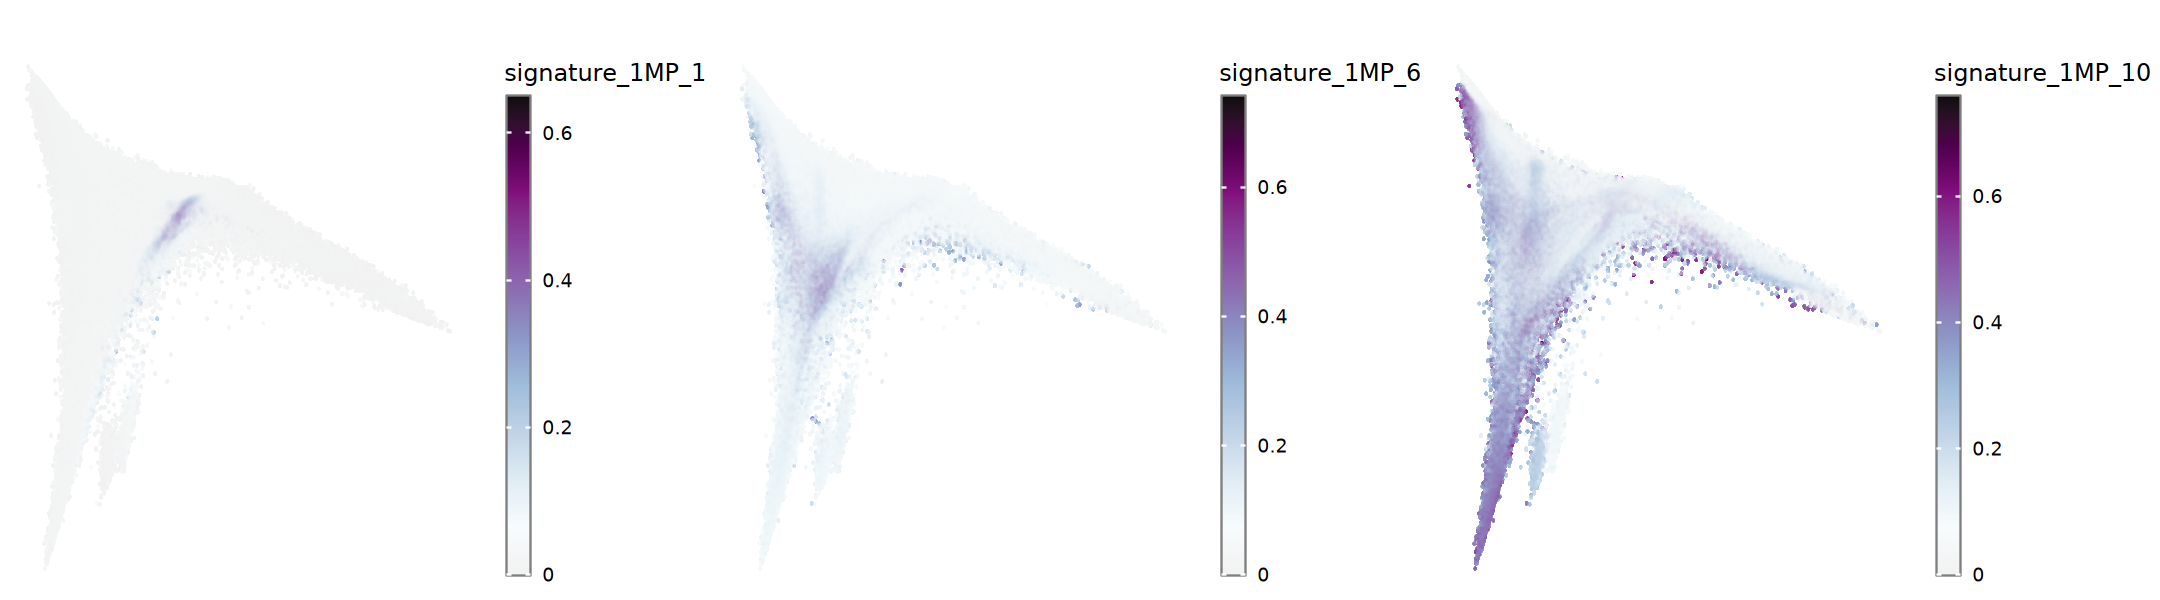

In [ ]:
options(repr.plot.height = 5, repr.plot.width = 18)
do_FeaturePlot(sample = malignant,reduction = 'diffusion',
               pt.size = 5,
               order=TRUE,
               ncol=3,
               sequential.palette='BuPu',
                dims = c(1,3), legend.position = 'right',
                  plot_cell_borders = FALSE,
                   raster = TRUE,
                features = c('signature_1MP_1',	
                             'signature_1MP_6',	
                             'signature_1MP_10'))

In [ ]:
ggsave('figures/core_programs_diffusion_map_malignant.pdf', height = 5, width = 18)